# GPT-2: Train a Decoder-Only Transformer From Scratch

## Project Overview

This project implements a lightweight GPT-2-style decoder-only Transformer
from scratch using PyTorch.

The objective is to understand and implement the fundamental components
behind modern Large Language Models, including:

- Tokenization
- Language modeling
- Self-attention
- Causal masking
- Multi-head attention
- Positional embeddings
- Feed-forward neural networks
- Residual connections
- Layer normalization
- Transformer blocks
- Autoregressive text generation

The model is trained on the Tiny Shakespeare dataset and learns to generate
Shakespeare-style text character by character.

In [1]:
!pip install torch matplotlib

In [2]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import matplotlib.pyplot as plt
import urllib.request

In [3]:
# Reproducibility
torch.manual_seed(1337)

# Select device
device = 'cuda' if torch.cuda.is_available() else 'cpu'

print("Device:", device)

Device: cuda


In [4]:
url = 'https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt'

with urllib.request.urlopen(url) as response:
    text = response.read().decode('utf-8')

print("Dataset size:", len(text))
print(text[:1000])

Dataset size: 1115394
First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us but the superfluity, while it were
wholesome, we might guess they relieved us humanely;
but they think we are too dear: the leanness that
afflicts us, the object of our misery, is as an
inventory to particularise their abundance; our
sufferance is a gain to them Let us revenge this with
our pikes, ere we become rakes: for the gods know I
speak this in hunger for bread, not in

## 1. Dataset Exploration

The dataset consists of Shakespeare's works represented as raw text.

Since this project uses character-level language modeling, every unique
character in the dataset becomes a token.

In [5]:
print("Total characters:", len(text))

chars = sorted(list(set(text)))

print("Unique characters:", len(chars))
print("Characters:", ''.join(chars))

Total characters: 1115394
Unique characters: 65
Characters: 
 !$&',-.3:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz


Character encoder/decoder

In [6]:
stoi = {ch: i for i, ch in enumerate(chars)}
itos = {i: ch for i, ch in enumerate(chars)}

encode = lambda s: [stoi[c] for c in s]
decode = lambda l: ''.join(itos[i] for i in l)

print(encode("Hello"))
print(decode(encode("Hello")))

[20, 43, 50, 50, 53]
Hello


Convert dataset to tensors

In [7]:
data = torch.tensor(encode(text), dtype=torch.long)

print(data.shape)
print(data[:100])

torch.Size([1115394])
tensor([18, 47, 56, 57, 58,  1, 15, 47, 58, 47, 64, 43, 52, 10,  0, 14, 43, 44,
        53, 56, 43,  1, 61, 43,  1, 54, 56, 53, 41, 43, 43, 42,  1, 39, 52, 63,
         1, 44, 59, 56, 58, 46, 43, 56,  6,  1, 46, 43, 39, 56,  1, 51, 43,  1,
        57, 54, 43, 39, 49,  8,  0,  0, 13, 50, 50, 10,  0, 31, 54, 43, 39, 49,
         6,  1, 57, 54, 43, 39, 49,  8,  0,  0, 18, 47, 56, 57, 58,  1, 15, 47,
        58, 47, 64, 43, 52, 10,  0, 37, 53, 59])


Train/validation split

In [8]:
n = int(0.9 * len(data))

train_data = data[:n]
val_data = data[n:]

print("Training characters:", len(train_data))
print("Validation characters:", len(val_data))

Training characters: 1003854
Validation characters: 111540


Batch generation

In [9]:
batch_size = 64
block_size = 128

def get_batch(split):
    data_source = train_data if split == 'train' else val_data

    ix = torch.randint(
        len(data_source) - block_size,
        (batch_size,)
    )

    x = torch.stack([
        data_source[i:i+block_size] for i in ix
    ])

    y = torch.stack([
        data_source[i+1:i+block_size+1] for i in ix
    ])

    return x.to(device), y.to(device)

In [10]:
#test
xb, yb = get_batch('train')

print("Input shape :", xb.shape)
print("Target shape:", yb.shape)

Input shape : torch.Size([64, 128])
Target shape: torch.Size([64, 128])


## 2. Bigram Language Model Baseline

Before implementing the Transformer, we establish a simple baseline using a
Bigram Language Model.

A bigram model predicts the next character using only the current character.

This provides a reference point to evaluate whether the Transformer architecture
learns better contextual relationships.

In [11]:
# Bigram Language Model

class BigramLanguageModel(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()

        # Each token directly maps to logits for the next token
        self.token_embedding_table = nn.Embedding(vocab_size, vocab_size)

    def forward(self, idx, targets=None):

        # idx shape: (B, T)
        logits = self.token_embedding_table(idx)

        # logits shape: (B, T, vocab_size)

        if targets is None:
            loss = None
        else:
            B, T, C = logits.shape

            logits = logits.view(B * T, C)
            targets = targets.view(B * T)

            loss = F.cross_entropy(logits, targets)

        return logits, loss

    def generate(self, idx, max_new_tokens):

        for _ in range(max_new_tokens):

            # Get predictions
            logits, loss = self(idx)

            # Focus only on the last time step
            logits = logits[:, -1, :]

            # Convert logits to probabilities
            probs = F.softmax(logits, dim=-1)

            # Sample next character
            idx_next = torch.multinomial(probs, num_samples=1)

            # Append generated character
            idx = torch.cat((idx, idx_next), dim=1)

        return idx

In [12]:
vocab_size = len(chars)

model = BigramLanguageModel(vocab_size)
model = model.to(device)

logits, loss = model(xb, yb)

print("Logits shape:", logits.shape)
print("Initial loss:", loss.item())

Logits shape: torch.Size([8192, 65])
Initial loss: 4.752943992614746


## 3. Model Training

The model is trained using cross-entropy loss and the AdamW optimizer.

We monitor both training and validation loss to evaluate learning and
generalization.

In [13]:
@torch.no_grad()
def estimate_loss(model, eval_iters=100):

    out = {}

    model.eval()

    for split in ['train', 'val']:

        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):

            X, Y = get_batch(split)

            _, loss = model(X, Y)

            losses[k] = loss.item()

        out[split] = losses.mean()

    model.train()

    return out

In [14]:
learning_rate = 1e-3
max_iters = 1000
eval_interval = 200

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate
)

train_losses = []
val_losses = []

for iter in range(max_iters):

    # Evaluate periodically
    if iter % eval_interval == 0:

        losses = estimate_loss(model)

        train_losses.append(losses['train'].item())
        val_losses.append(losses['val'].item())

        print(
            f"Step {iter}: "
            f"train loss {losses['train']:.4f}, "
            f"val loss {losses['val']:.4f}"
        )

    # Get batch
    xb, yb = get_batch('train')

    # Forward pass
    logits, loss = model(xb, yb)

    # Clear gradients
    optimizer.zero_grad(set_to_none=True)

    # Backpropagation
    loss.backward()

    # Update parameters
    optimizer.step()

Step 0: train loss 4.7510, val loss 4.7587
Step 200: train loss 4.4608, val loss 4.4683
Step 400: train loss 4.1973, val loss 4.2048
Step 600: train loss 3.9597, val loss 3.9703
Step 800: train loss 3.7491, val loss 3.7600


Generate text from the baseline

In [15]:
context = torch.zeros((1, 1), dtype=torch.long, device=device)

generated = model.generate(
    context,
    max_new_tokens=500
)

print(decode(generated[0].tolist()))


WYCz$bMyRZk
gc'wi,ZT,OLla,xbtK
gaiGeCNMBFzou3:BaSGBO-3DSM:
CKLTauss:LVXJthNeNuwqhPM$v.t?V; dXENDoaAesuwacePOzEFKfDsZaYzyzoINuX
Yow&$
MUUfVitENq!!&V! l;FdilK!,ue3:ivYeY?YBkcinjlaP;Hmaiv;ov EcSXE3;qWknd.gGy!.gPrjus!
elJlindAUThP.T-huDZqcdchXVN:?Uug;Mnissp3Uw y.TH'sYPUSIkyB
SpeYelavIENq'mqhyqETdqmotS?dqeoyW-SQkhQujVCerib3qe'ThtmFKE$HzvETENe,hQm$Fs C-LAR:AN-z'tH
D:xkwomnunrupW&f s
;;3;rDLWTh:fnt,CIy.flPUE$tw,fMf PrD?dqK'S? .UrHK-NLAk!
r,JSb&i&a
SrdaplWZ$!
E'D:
YBvuin cmik?VU'aAnyyRr-ptsSI&cn VEc!NMy


## 4. Baseline Training Results

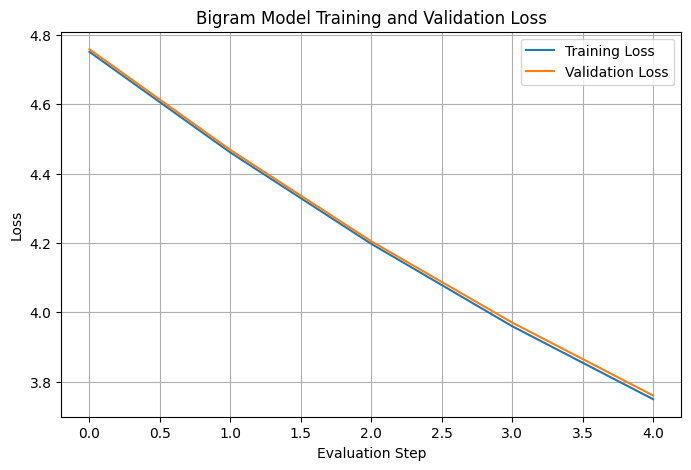

In [16]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')

plt.xlabel('Evaluation Step')
plt.ylabel('Loss')
plt.title('Bigram Model Training and Validation Loss')

plt.legend()
plt.grid(True)

plt.show()

## 5. Self-Attention

Self-attention allows each token to determine which previous tokens are
important for predicting the next token.

For autoregressive language modeling, we use causal self-attention so that
a token cannot access information from future positions.

In [17]:
# Simple self-attention demonstration

B, T, C = 4, 8, 32

x = torch.randn(B, T, C)

head_size = 16

key = nn.Linear(C, head_size, bias=False)
query = nn.Linear(C, head_size, bias=False)
value = nn.Linear(C, head_size, bias=False)

k = key(x)
q = query(x)

# Attention scores
wei = q @ k.transpose(-2, -1)

print("Attention score shape:", wei.shape)

Attention score shape: torch.Size([4, 8, 8])


Causal Masking

In [18]:
# Causal mask

tril = torch.tril(torch.ones(T, T))

wei = wei.masked_fill(
    tril == 0,
    float('-inf')
)

wei = F.softmax(wei, dim=-1)

print(wei[0])

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.9137, 0.0863, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.0907, 0.5734, 0.3359, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1370, 0.5298, 0.2587, 0.0745, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2917, 0.1283, 0.2733, 0.2804, 0.0264, 0.0000, 0.0000, 0.0000],
        [0.2248, 0.2239, 0.2908, 0.1016, 0.0145, 0.1445, 0.0000, 0.0000],
        [0.0110, 0.1105, 0.0313, 0.0939, 0.3546, 0.0190, 0.3798, 0.0000],
        [0.0722, 0.0762, 0.3488, 0.1477, 0.0358, 0.2045, 0.0722, 0.0425]],
       grad_fn=<SelectBackward0>)


## 6. Causal Self-Attention Head

A causal self-attention head learns relationships between tokens while
preventing information from future positions from being accessed.

The attention mechanism uses:

- Query (Q)
- Key (K)
- Value (V)

Attention is calculated as:

Attention(Q,K,V) = softmax(QKᵀ / √dₖ)V

A lower-triangular causal mask ensures that each token can only attend
to itself and previous tokens.

In [20]:
# Transformer configuration

batch_size = 64
block_size = 128

n_embd = 128
n_head = 4
n_layer = 4

dropout = 0.1

vocab_size = len(chars)

print("Vocabulary size:", vocab_size)
print("Embedding dimension:", n_embd)
print("Number of heads:", n_head)
print("Number of layers:", n_layer)

Vocabulary size: 65
Embedding dimension: 128
Number of heads: 4
Number of layers: 4


In [21]:
class Head(nn.Module):
    """One head of causal self-attention."""

    def __init__(self, head_size):
        super().__init__()

        self.key = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)

        # Causal mask
        self.register_buffer(
            'tril',
            torch.tril(torch.ones(block_size, block_size))
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        B, T, C = x.shape

        # Compute Query and Key
        k = self.key(x)
        q = self.query(x)

        # Attention scores
        wei = q @ k.transpose(-2, -1)

        # Scale attention scores
        wei = wei * (C ** -0.5)

        # Apply causal mask
        wei = wei.masked_fill(
            self.tril[:T, :T] == 0,
            float('-inf')
        )

        # Convert scores to probabilities
        wei = F.softmax(wei, dim=-1)

        wei = self.dropout(wei)

        # Weighted aggregation of values
        v = self.value(x)

        out = wei @ v

        return out

## 7. Multi-Head Self-Attention

Multi-head attention runs several self-attention heads in parallel.

Different heads can learn different relationships between tokens.

The outputs of all attention heads are concatenated and projected back
into the embedding dimension.

In [22]:
class MultiHeadAttention(nn.Module):

    def __init__(self, num_heads, head_size):
        super().__init__()

        self.heads = nn.ModuleList(
            [Head(head_size) for _ in range(num_heads)]
        )

        self.proj = nn.Linear(
            num_heads * head_size,
            n_embd
        )

        self.dropout = nn.Dropout(dropout)

    def forward(self, x):

        # Run attention heads in parallel
        out = torch.cat(
            [h(x) for h in self.heads],
            dim=-1
        )

        # Project concatenated output
        out = self.proj(out)

        out = self.dropout(out)

        return out

## 8. Feed-Forward Network

The feed-forward network applies a nonlinear transformation independently
to each token representation.

It consists of two linear layers with a ReLU activation between them.

The hidden dimension is expanded before being projected back to the
embedding dimension.

In [24]:
class FeedForward(nn.Module):

    def __init__(self, n_embd):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.ReLU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        return self.net(x)

## 9. Transformer Block

A Transformer block combines:

1. Layer normalization
2. Multi-head causal self-attention
3. Residual connection
4. Feed-forward network
5. Another residual connection

Residual connections help preserve information and improve gradient flow
during training.

In [25]:
class Block(nn.Module):

    def __init__(self, n_embd, n_head):
        super().__init__()

        head_size = n_embd // n_head

        self.sa = MultiHeadAttention(
            n_head,
            head_size
        )

        self.ffwd = FeedForward(n_embd)

        self.ln1 = nn.LayerNorm(n_embd)
        self.ln2 = nn.LayerNorm(n_embd)

    def forward(self, x):

        # Attention + residual connection
        x = x + self.sa(self.ln1(x))

        # Feed-forward + residual connection
        x = x + self.ffwd(self.ln2(x))

        return x

## 10. GPT Language Model

The final model is a decoder-only Transformer consisting of:

- Token embeddings
- Positional embeddings
- Multiple Transformer blocks
- Final layer normalization
- Language modeling head

The model predicts the next token autoregressively.

In [26]:
class GPTLanguageModel(nn.Module):

    def __init__(self):
        super().__init__()

        # Token embeddings
        self.token_embedding_table = nn.Embedding(
            vocab_size,
            n_embd
        )

        # Positional embeddings
        self.position_embedding_table = nn.Embedding(
            block_size,
            n_embd
        )

        # Transformer blocks
        self.blocks = nn.Sequential(
            *[
                Block(n_embd, n_head)
                for _ in range(n_layer)
            ]
        )

        # Final layer normalization
        self.ln_f = nn.LayerNorm(n_embd)

        # Language modeling head
        self.lm_head = nn.Linear(
            n_embd,
            vocab_size
        )

        # Weight initialization
        self.apply(self._init_weights)

    def _init_weights(self, module):

        if isinstance(module, nn.Linear):
            torch.nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

            if module.bias is not None:
                torch.nn.init.zeros_(module.bias)

        elif isinstance(module, nn.Embedding):
            torch.nn.init.normal_(
                module.weight,
                mean=0.0,
                std=0.02
            )

    def forward(self, idx, targets=None):

        B, T = idx.shape

        # Token embeddings
        tok_emb = self.token_embedding_table(idx)

        # Positional embeddings
        pos_emb = self.position_embedding_table(
            torch.arange(T, device=device)
        )

        # Combine token + positional information
        x = tok_emb + pos_emb

        # Transformer blocks
        x = self.blocks(x)

        # Final normalization
        x = self.ln_f(x)

        # Vocabulary logits
        logits = self.lm_head(x)

        if targets is None:

            loss = None

        else:

            B, T, C = logits.shape

            logits = logits.view(B * T, C)
            targets = targets.view(B * T)

            loss = F.cross_entropy(
                logits,
                targets
            )

        return logits, loss

    def generate(self, idx, max_new_tokens):

        for _ in range(max_new_tokens):

            # Keep only the latest context window
            idx_cond = idx[:, -block_size:]

            # Forward pass
            logits, loss = self(idx_cond)

            # Take last prediction
            logits = logits[:, -1, :]

            # Convert to probabilities
            probs = F.softmax(logits, dim=-1)

            # Sample next token
            idx_next = torch.multinomial(
                probs,
                num_samples=1
            )

            # Append token
            idx = torch.cat(
                (idx, idx_next),
                dim=1
            )

        return idx

Create the GPT

In [27]:
model = GPTLanguageModel()
model = model.to(device)

print(model)

# Count parameters
num_params = sum(
    p.numel()
    for p in model.parameters()
)

print(
    f"\nTotal parameters: {num_params:,}"
)

GPTLanguageModel(
  (token_embedding_table): Embedding(65, 128)
  (position_embedding_table): Embedding(128, 128)
  (blocks): Sequential(
    (0): Block(
      (sa): MultiHeadAttention(
        (heads): ModuleList(
          (0-3): 4 x Head(
            (key): Linear(in_features=128, out_features=32, bias=False)
            (query): Linear(in_features=128, out_features=32, bias=False)
            (value): Linear(in_features=128, out_features=32, bias=False)
            (dropout): Dropout(p=0.1, inplace=False)
          )
        )
        (proj): Linear(in_features=128, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (ffwd): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=128, out_features=512, bias=True)
          (1): ReLU()
          (2): Linear(in_features=512, out_features=128, bias=True)
          (3): Dropout(p=0.1, inplace=False)
        )
      )
      (ln1): LayerNorm((128,), eps=1e-05, elementwise_affine=T

In [28]:
#Test before training
xb, yb = get_batch('train')

logits, loss = model(xb, yb)

print("Input shape :", xb.shape)
print("Logits shape:", logits.shape)
print("Initial loss:", loss.item())

Input shape : torch.Size([64, 128])
Logits shape: torch.Size([8192, 65])
Initial loss: 4.153951168060303


## 11. Training the GPT Model

The Transformer is trained using next-token prediction.

For every input sequence, the model predicts the character that follows
each position.

Cross-entropy loss measures the difference between the predicted probability
distribution and the actual next character.

AdamW is used as the optimizer.

In [29]:
# GPT Training Configuration

learning_rate = 3e-4
max_iters = 3000
eval_interval = 300
eval_iters = 50

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=learning_rate
)

train_losses_gpt = []
val_losses_gpt = []

print("Starting GPT training...")

Starting GPT training...


In [30]:
@torch.no_grad()
def estimate_gpt_loss(model, eval_iters=50):

    out = {}

    model.eval()

    for split in ['train', 'val']:

        losses = torch.zeros(eval_iters)

        for k in range(eval_iters):

            X, Y = get_batch(split)

            _, loss = model(X, Y)

            losses[k] = loss.item()

        out[split] = losses.mean()

    model.train()

    return out


for iter in range(max_iters):

    # Evaluate model periodically
    if iter % eval_interval == 0:

        losses = estimate_gpt_loss(
            model,
            eval_iters
        )

        train_loss = losses['train'].item()
        val_loss = losses['val'].item()

        train_losses_gpt.append(train_loss)
        val_losses_gpt.append(val_loss)

        print(
            f"Step {iter:4d} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f}"
        )

    # Get training batch
    xb, yb = get_batch('train')

    # Forward pass
    logits, loss = model(xb, yb)

    # Clear previous gradients
    optimizer.zero_grad(set_to_none=True)

    # Backpropagation
    loss.backward()

    # Update weights
    optimizer.step()

print("Training completed!")

Step    0 | Train Loss: 4.1492 | Val Loss: 4.1490
Step  300 | Train Loss: 2.3658 | Val Loss: 2.3800
Step  600 | Train Loss: 1.9961 | Val Loss: 2.0606
Step  900 | Train Loss: 1.7259 | Val Loss: 1.8846
Step 1200 | Train Loss: 1.6001 | Val Loss: 1.7827
Step 1500 | Train Loss: 1.5266 | Val Loss: 1.7155
Step 1800 | Train Loss: 1.4812 | Val Loss: 1.6580
Step 2100 | Train Loss: 1.4436 | Val Loss: 1.6435
Step 2400 | Train Loss: 1.4170 | Val Loss: 1.6158
Step 2700 | Train Loss: 1.3953 | Val Loss: 1.5941
Training completed!


## 12. GPT Training Results

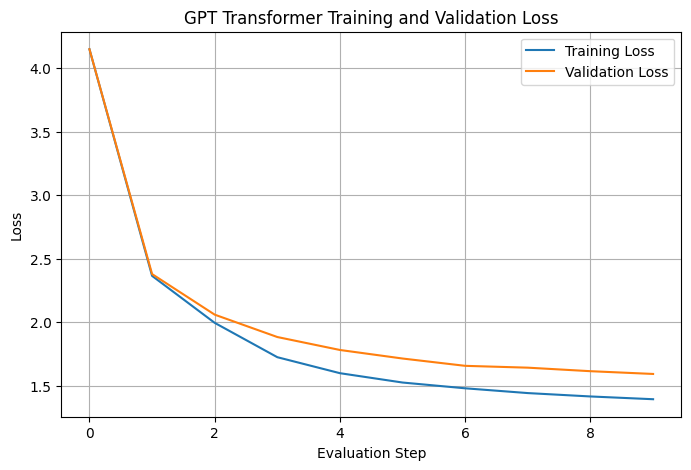

In [31]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_losses_gpt,
    label='Training Loss'
)

plt.plot(
    val_losses_gpt,
    label='Validation Loss'
)

plt.xlabel('Evaluation Step')
plt.ylabel('Loss')

plt.title(
    'GPT Transformer Training and Validation Loss'
)

plt.legend()
plt.grid(True)

plt.show()

## 13. Baseline vs Transformer

The Bigram model provides a simple baseline that considers very limited
context.

The GPT-style Transformer uses causal self-attention and multiple
Transformer blocks to model longer-range dependencies.

Comparing their validation losses demonstrates the improvement achieved
through the Transformer architecture.

In [32]:
print("Bigram final validation loss:",
      val_losses[-1])

print("GPT final validation loss:",
      val_losses_gpt[-1])

improvement = (
    (val_losses[-1] - val_losses_gpt[-1])
    / val_losses[-1]
) * 100

print(
    f"Validation loss improvement: {improvement:.2f}%"
)

Bigram final validation loss: 3.7599713802337646
GPT final validation loss: 1.5941145420074463
Validation loss improvement: 57.60%


## 14. Text Generation

The trained model generates text autoregressively.

At each step, the model predicts a probability distribution over the
vocabulary, samples the next character, and feeds that character back
into the model as part of the context.

In [33]:
# Generate text

model.eval()

context = torch.zeros(
    (1, 1),
    dtype=torch.long,
    device=device
)

generated = model.generate(
    context,
    max_new_tokens=1000
)

generated_text = decode(
    generated[0].tolist()
)

print(generated_text)


Remember revenged them I am laid English.

DUKE OF YORK:
Both your greet in the which be a shade.

DUKE VINCENTIO:
Good, not Dest liquire togethan did to you:
For you to hear her lack! when gone of withled
In set to from to a! that retire it was him well;
And I be birth? here is at it seasided,
For Cates and his the strimments presss!
O, Clifford, if I, there will or cold you to grow:
Mehough do regrace wilt there very son:
There, like a thiurs Lewis; if thou do my sweet privant make it
Provons here chae note, if let you not good;
And in passor, loss she, in when it which Pomfardis,
As then me dead?

BUCKINGHAM:
Thou sume may, degr what served, as him old and
The will no staid more and children,
So I went on speak play a name,
It otraitions fliewigh, even time us reccept from these?
Secousrand war of our heart him a fathous, I go hear be
In block in him, something to in how where I doth
Marriagl and danger conce'd take a friendshing,
And which with him the muster' heart, I unforce prt

Make generation better

In [34]:

prompt = "ROMEO:"

context = torch.tensor(
    [encode(prompt)],
    dtype=torch.long,
    device=device
)

generated = model.generate(
    context,
    max_new_tokens=500
)

print(
    decode(generated[0].tolist())
)

ROMEO:
What is to so the duke again, quickly it from for
To say that this sake upon the deck's craced
I'll the one of a great die to a virtue.

Nurse:
Wrick, what I?

MERCUTIO:

OUCHESS:
Why, that is business on a desconceive
The pursuation he is the sone of than your
To appear them post me regndle us, grim'd by how,
And prom me soper; I than say with a prock,
Shall kill ylding; your duke and whise
uncocesting his partue to the curse.

QUEEEN MARGINLHAND:
What, more is.

HENRY VI

Second Pitizen:
What


## 15. Temperature-Controlled Text Generation

Temperature controls the randomness of the model's predictions.

- Lower temperature produces more predictable text.
- Higher temperature produces more diverse and creative text.

This parameter will also be exposed in the deployment interface.

In [35]:
def generate_text(prompt, max_new_tokens=500, temperature=0.8):

    model.eval()

    context = torch.tensor(
        [encode(prompt)],
        dtype=torch.long,
        device=device
    )

    for _ in range(max_new_tokens):

        # Keep only the latest context window
        idx_cond = context[:, -block_size:]

        # Model prediction
        logits, _ = model(idx_cond)

        # Get prediction for final position
        logits = logits[:, -1, :]

        # Apply temperature
        logits = logits / temperature

        # Convert to probabilities
        probs = F.softmax(logits, dim=-1)

        # Sample next character
        next_token = torch.multinomial(
            probs,
            num_samples=1
        )

        # Add token to context
        context = torch.cat(
            (context, next_token),
            dim=1
        )

    return decode(context[0].tolist())

In [36]:
print(
    generate_text(
        "ROMEO:",
        max_new_tokens=500,
        temperature=0.8
    )
)

ROMEO:
You have been to my life.

LORD FITHAS OF GAUNT:
Come, sir, that, call him me to thy sun.
Fire, my lord sovereige that for thy stabed,
Shall be for the blood of with thy with the craves.
I would afford the kingd me live.

Third Saint:
I have as that your duke compless.

DUKE VINCENTIO:
It he were did of utter: I princely.

ROMEO:
My lord ungrath me: I may would than
The dark oath cousin live with for is sture
To businnesting him status that have like my son,
By that any thou canst thou and can 


In [37]:
print(
    generate_text(
        "KING:",
        max_new_tokens=500,
        temperature=0.7
    )
)

KING:
It the heart, that will my son and run give
He both the tranking for our house what be
This heart to the prince which they fear loves:
When I do have dear, no asking to love that here?
Therefore the spring of Romeo alter.

First Servant:
What, they shall be that it the such done?

DUKE VINCENTIO:
You do love thee and now, do being it, but it it on the
to the gear in hand to him a friend; my swords,
Married me, that doth light love the fortuness:
You have the stumble to day.

JULIET:
Give me me 


In [38]:
print(
    generate_text(
        "To be",
        max_new_tokens=500,
        temperature=0.9
    )
)

To be, they subject me more fortune,
That I must know all the pleasation
To hear such lords you see a time face,
By perator's purpose to in thy heeavs,
Nor grief now friends Pomfolk about,
And that husband five more for more with you.
The seaso worn to him Volscip your pierces.

CLARENCE:
I can it all ear deam. For no him?
'Tis high the seer-hrant serve:
For he which a straige the lies or good
freedly, here me for fastle to me thous
And smel our comfortune's hold forgund never,
That mercy whether sho


## 16. Saving the Trained Model

The trained model weights are saved as a PyTorch checkpoint so that the
model can be reused for inference and deployment without retraining.

In [39]:
checkpoint = {
    "model_state_dict": model.state_dict(),

    "vocab_size": vocab_size,
    "n_embd": n_embd,
    "n_head": n_head,
    "n_layer": n_layer,
    "block_size": block_size,
    "dropout": dropout,

    "stoi": stoi,
    "itos": itos
}

torch.save(
    checkpoint,
    "mini_gpt2_shakespeare.pt"
)

print("Model saved successfully!")

Model saved successfully!


In [40]:
import os

file_size = os.path.getsize(
    "mini_gpt2_shakespeare.pt"
) / (1024 * 1024)

print(
    f"Checkpoint size: {file_size:.2f} MB"
)-

Checkpoint size: 4.19 MB


Downloading the model checkpoint

In [41]:
from google.colab import files

files.download(
    "mini_gpt2_shakespeare.pt"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 17. Architecture Summary

The final Mini GPT-2 model follows a decoder-only Transformer architecture.

### Architecture

Input Characters
↓
Character Tokenization
↓
Token Embeddings
+
Positional Embeddings
↓
Transformer Block × 4
↓
Multi-Head Causal Self-Attention
↓
Feed-Forward Network
↓
Residual Connections
↓
Layer Normalization
↓
Linear Language Modeling Head
↓
Next Character Prediction

### Model Configuration

- Vocabulary Size: 65
- Embedding Dimension: 128
- Attention Heads: 4
- Transformer Layers: 4
- Context Length: 128
- Dropout: 0.1
- Total Parameters: 824,897

# 18. Conclusion

This project demonstrates the implementation and training of a lightweight
GPT-2-style decoder-only Transformer completely from scratch using PyTorch.

The project progressed from a simple Bigram Language Model to a complete
Transformer architecture with causal self-attention, multi-head attention,
positional embeddings, feed-forward networks, residual connections and
layer normalization.

The GPT-style Transformer achieved a validation loss of approximately 1.59,
compared with 3.76 for the Bigram baseline, representing approximately a
57.6% reduction in validation loss.

The trained model is capable of generating Shakespeare-style text
autoregressively from user-provided prompts.

The trained model is subsequently packaged for interactive deployment.

In [42]:
checkpoint = {
    "model_state_dict": model.state_dict(),
    "vocab_size": vocab_size,
    "n_embd": n_embd,
    "n_head": n_head,
    "n_layer": n_layer,
    "block_size": block_size,
    "dropout": dropout,
    "stoi": stoi,
    "itos": itos
}

torch.save(
    checkpoint,
    "mini_gpt2_shakespeare.pt"
)

print("Model saved successfully!")

Model saved successfully!


In [43]:
import os

file_size = os.path.getsize(
    "mini_gpt2_shakespeare.pt"
) / (1024 * 1024)

print(f"Checkpoint size: {file_size:.2f} MB")

Checkpoint size: 4.19 MB
